Day1

In [3]:
##pip install tensorflow[and-cuda]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import tensorflow as tf
import kagglehub
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("preetviradiya/brian-tumor-dataset")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:06<00:00, 18.7MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1


In [6]:
print(os.listdir(path))

['Brain Tumor Data Set', 'metadata_rgb_only.csv', 'metadata.csv']


In [7]:
images_path=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Brain Tumor")
print(images_path)

/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Brain Tumor


In [8]:
print(len(os.listdir(images_path)))
print(os.listdir(images_path)[:5])

2513
['Cancer (590).jpg', 'Cancer (287).jpg', 'Cancer (1065).jpg', 'Cancer (368).jpg', 'Cancer (1327).jpg']


In [9]:
import pandas as pd
import os

data = []

folder_name = "Brain Tumor"
count = len(os.listdir(images_path))

data.append((folder_name, count))

print(f"{folder_name}: {count} images")

df = pd.DataFrame(data, columns=["Class", "Count"])
df

Brain Tumor: 2513 images


,Class,Count
0,Brain Tumor,2513


In [11]:
images_pathhealthy=os.path.join(path,'Brain Tumor Data Set',"Brain Tumor Data Set", "Healthy")
print(images_pathhealthy)

/root/.cache/kagglehub/datasets/preetviradiya/brian-tumor-dataset/versions/1/Brain Tumor Data Set/Brain Tumor Data Set/Healthy


In [12]:
print(len(os.listdir(images_pathhealthy)))
print(os.listdir(images_pathhealthy)[:5])

2087
['Not Cancer  (1658).jpg', 'Not Cancer  (1328).jpg', 'Not Cancer  (1167).jpg', 'Not Cancer  (200).jpg', 'Not Cancer  (470).jpg']


In [14]:
import pandas as pd
import os

data = []

# Brain Tumor
tumor_images = [img for img in os.listdir(images_path) if img.endswith(('.jpg', '.png', '.tif'))]
tumor_count = len(tumor_images)
data.append(("Brain Tumor", tumor_count))

print(f"Brain Tumor: {tumor_count} images")

# Healthy
healthy_images = [img for img in os.listdir(images_pathhealthy) if img.endswith(('.jpg', '.png', '.tif'))]
healthy_count = len(healthy_images)
data.append(("Healthy", healthy_count))

print(f"Healthy: {healthy_count} images")


# Create DataFrame
df = pd.DataFrame(data, columns=["Class", "Count"])

df

Brain Tumor: 2445 images
Healthy: 2075 images


,Class,Count
0,Brain Tumor,2445
1,Healthy,2075


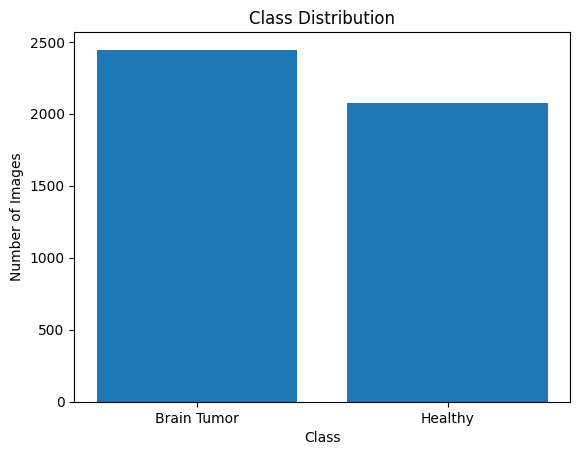

In [15]:
plt.bar(df["Class"], df["Count"])
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [17]:
from PIL import Image
import os

sizes = []

# Brain Tumor images
for img_name in os.listdir(images_path)[:50]:  # sample
    img_path = os.path.join(images_path, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

# Healthy images
for img_name in os.listdir(images_pathhealthy)[:50]:  # sample
    img_path = os.path.join(images_pathhealthy, img_name)
    img = Image.open(img_path)
    sizes.append(img.size)

print("Sample Image Sizes:", sizes[:10])

Sample Image Sizes: [(512, 512), (512, 512), (630, 630), (512, 512), (306, 365), (300, 336), (283, 295), (512, 512), (314, 340), (512, 512)]


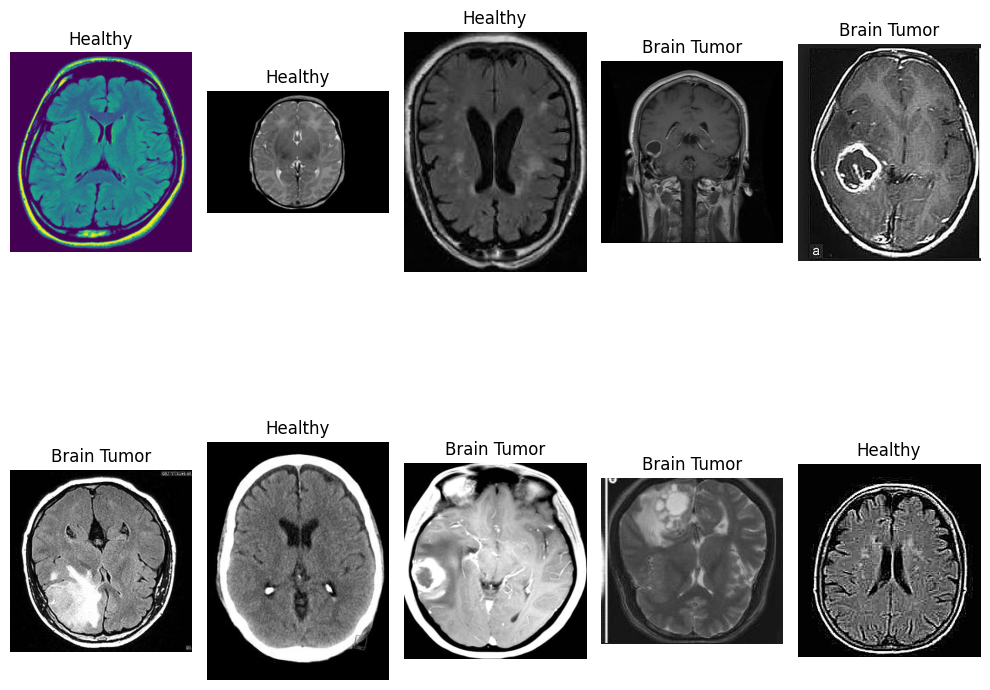

In [18]:
import matplotlib.pyplot as plt
import random
import os

plt.figure(figsize=(10, 10))

for i in range(10):

    # Randomly choose class
    if random.random() > 0.5:
        folder = "Brain Tumor"
        folder_path = images_path
    else:
        folder = "Healthy"
        folder_path = images_pathhealthy

    # Pick random image
    img_name = random.choice(os.listdir(folder_path))
    img_path = os.path.join(folder_path, img_name)

    img = plt.imread(img_path)

    plt.subplot(2, 5, i+1)
    plt.imshow(img)
    plt.title(folder)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [26]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image mode:", img.mode)

Image mode: L


In [27]:
from PIL import Image

img = Image.open(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image mode:", img.mode)

Image mode: RGB


In [20]:
from PIL import Image

corrupted = 0

for img_name in os.listdir(images_path):
    try:
        img = Image.open(os.path.join(images_path, img_name))
    except:
        corrupted += 1

print("Corrupted images:", corrupted)

Corrupted images: 0


In [29]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Image shape:", img.shape)

Image shape: (512, 512, 3)


In [28]:
import numpy as np

img = plt.imread(os.path.join(images_path, os.listdir(images_path)[5]))
print("Image shape:", img.shape)

Image shape: (336, 300)


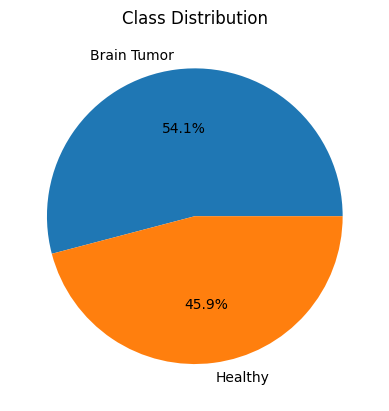

In [22]:
plt.pie(df["Count"], labels=df["Class"], autopct='%1.1f%%')
plt.title("Class Distribution")
plt.show()

In [23]:
label_map = {
    "Healthy": 0,
    "Brain Tumor": 1
}

print(label_map)

{'Healthy': 0, 'Brain Tumor': 1}


In [24]:
img = plt.imread(os.path.join(images_path, os.listdir(images_path)[0]))
print("Min pixel:", img.min())
print("Max pixel:", img.max())

Min pixel: 0
Max pixel: 255
